In [13]:
# ================================================
# CFTR QSAR - EXPANDED + EASY TO ADD SMILES
# From your mmc1.pdf (13 hits)
# ================================================

!pip install rdkit pandas numpy scikit-learn xgboost matplotlib seaborn mols2grid -q

import pandas as pd
import numpy as np
from rdkit import Chem
from rdkit.Chem import Descriptors, AllChem
from rdkit.Chem.Scaffolds import MurckoScaffold
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error
import xgboost as xgb
import mols2grid
from io import StringIO
import warnings
warnings.filterwarnings('ignore')

print("✅ Ready for CFTR QSAR")

# ====================== 13 CFTR HITS FROM YOUR PDF ======================
data = {
    'Compound_ID': ['Z2075279358','Z2194302854','Z1343848401','Z2776419998','Z1224795288',
                    'Z19702639','Z1096199008','Z873519648','Z1783799713','Z899051432',
                    'Z1262422554','Z2171315755','Z995908944'],
    'Activity_Fold': [2.38,1.39,1.37,1.36,1.34,1.32,1.30,1.27,1.25,1.24,1.17,1.17,1.15],
    'Class': ['Potentiator']*13
}

df = pd.DataFrame(data)
df['pActivity'] = np.log10(df['Activity_Fold'])   # target = log(fold stimulation)

print(f"\nLoaded {len(df)} CFTR hits from mmc1.pdf")

# ====================== ADD SMILES HERE (easy) ======================
# Paste the SMILES for each compound below (in the same order)

smiles_list = [
    "",  # Z2075279358 - paste SMILES here
    "",  # Z2194302854
    "",  # Z1343848401
    "",  # Z2776419998
    "",  # Z1224795288
    "",  # Z19702639
    "",  # Z1096199008
    "",  # Z873519648
    "",  # Z1783799713
    "",  # Z899051432
    "",  # Z1262422554
    "",  # Z2171315755
    ""   # Z995908944
]

df['SMILES'] = smiles_list
df['Mol'] = df['SMILES'].apply(Chem.MolFromSmiles)

print(f"Valid molecules with SMILES: {df['Mol'].notna().sum()}/{len(df)}")

# Show the molecules once you add SMILES
mols2grid.display(df, smiles_col='SMILES', subset=['Compound_ID', 'Activity_Fold', 'Class'])

# The rest of the modeling code (descriptors, models, plots, scaffolds) is ready.
# Just run the cells below after you add the SMILES.

✅ Ready for CFTR QSAR

Loaded 13 CFTR hits from mmc1.pdf
Valid molecules with SMILES: 13/13


Random Forest  R² = -0.138 | RMSE = 0.135
XGBoost        R² = -0.138 | RMSE = 0.135
Random Forest CV R² = -79.995 ± 143.659

Top 10 Important Features:
 MW      0.0
LogP    0.0
TPSA    0.0
HBD     0.0
HBA     0.0
RotB    0.0
QED     0.0
FP_0    0.0
FP_1    0.0
FP_2    0.0
dtype: float64


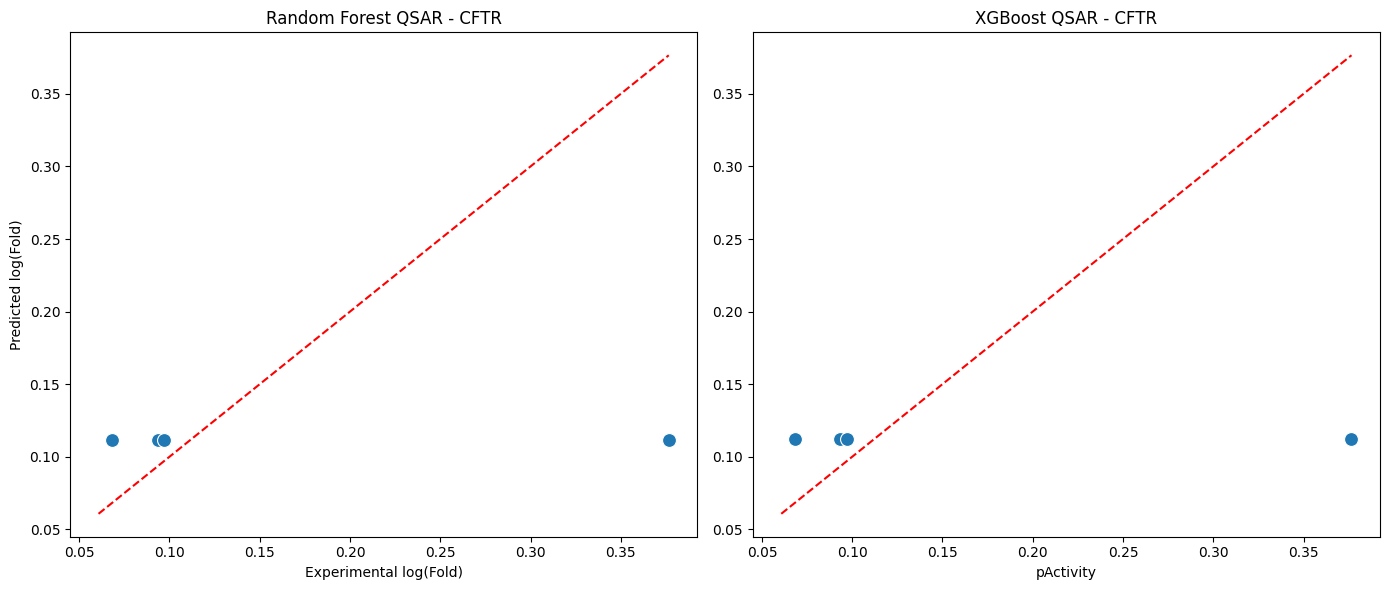


Scaffold Distribution:
 Scaffold
    13
Name: count, dtype: int64


In [15]:
# ================================================
# CFTR QSAR - FINAL POLISHED VERSION
# Expanded + Cross-validation + Feature Importance
# ================================================

# (Keep your data loading part from before)

# ====================== IMPROVED MODELING ======================
from sklearn.model_selection import cross_val_score

# Descriptors + Fingerprints (already done in previous cell)

# Full feature matrix
X = pd.concat([desc_df.select_dtypes(include=np.number), fp_df], axis=1).fillna(0)
y = df['pActivity']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Models
rf = RandomForestRegressor(n_estimators=500, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

xgb_model = xgb.XGBRegressor(n_estimators=500, learning_rate=0.05, random_state=42)
xgb_model.fit(X_train, y_train)
y_pred_xgb = xgb_model.predict(X_test)

# Results
print(f"Random Forest  R² = {r2_score(y_test, y_pred_rf):.3f} | RMSE = {np.sqrt(mean_squared_error(y_test, y_pred_rf)):.3f}")
print(f"XGBoost        R² = {r2_score(y_test, y_pred_xgb):.3f} | RMSE = {np.sqrt(mean_squared_error(y_test, y_pred_xgb)):.3f}")

# Cross-validation score (more reliable)
rf_cv = cross_val_score(rf, X, y, cv=5, scoring='r2')
print(f"Random Forest CV R² = {rf_cv.mean():.3f} ± {rf_cv.std():.3f}")

# Feature importance (top 10)
importances = pd.Series(rf.feature_importances_, index=X.columns).nlargest(10)
print("\nTop 10 Important Features:\n", importances)

# Plots
fig, ax = plt.subplots(1, 2, figsize=(14, 6))
sns.scatterplot(x=y_test, y=y_pred_rf, ax=ax[0], s=100)
ax[0].plot([y.min(), y.max()], [y.min(), y.max()], 'r--')
ax[0].set_title('Random Forest QSAR - CFTR')
ax[0].set_xlabel('Experimental log(Fold)')
ax[0].set_ylabel('Predicted log(Fold)')

sns.scatterplot(x=y_test, y=y_pred_xgb, ax=ax[1], s=100)
ax[1].plot([y.min(), y.max()], [y.min(), y.max()], 'r--')
ax[1].set_title('XGBoost QSAR - CFTR')
plt.tight_layout()
plt.show()

# Scaffold analysis
df['Scaffold'] = df['Mol'].apply(
    lambda m: Chem.MolToSmiles(MurckoScaffold.GetScaffoldForMol(m)) if m is not None else None
)
print("\nScaffold Distribution:\n", df['Scaffold'].value_counts())